In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from tulip import spatial

In [4]:
tiff_file = "/mnt/c/Users/Roger/Documents/Doctoral Studies/Data/2022_02_01-CellDive/mask/VAN0061-LK-2-6-cell-mask.tiff"

In [5]:
a = spatial(nar_ids=np.array([0]))
a.from_tiff(tiff_file, 10000, 10000, 512, 512) # test

TypeError: 'module' object is not callable

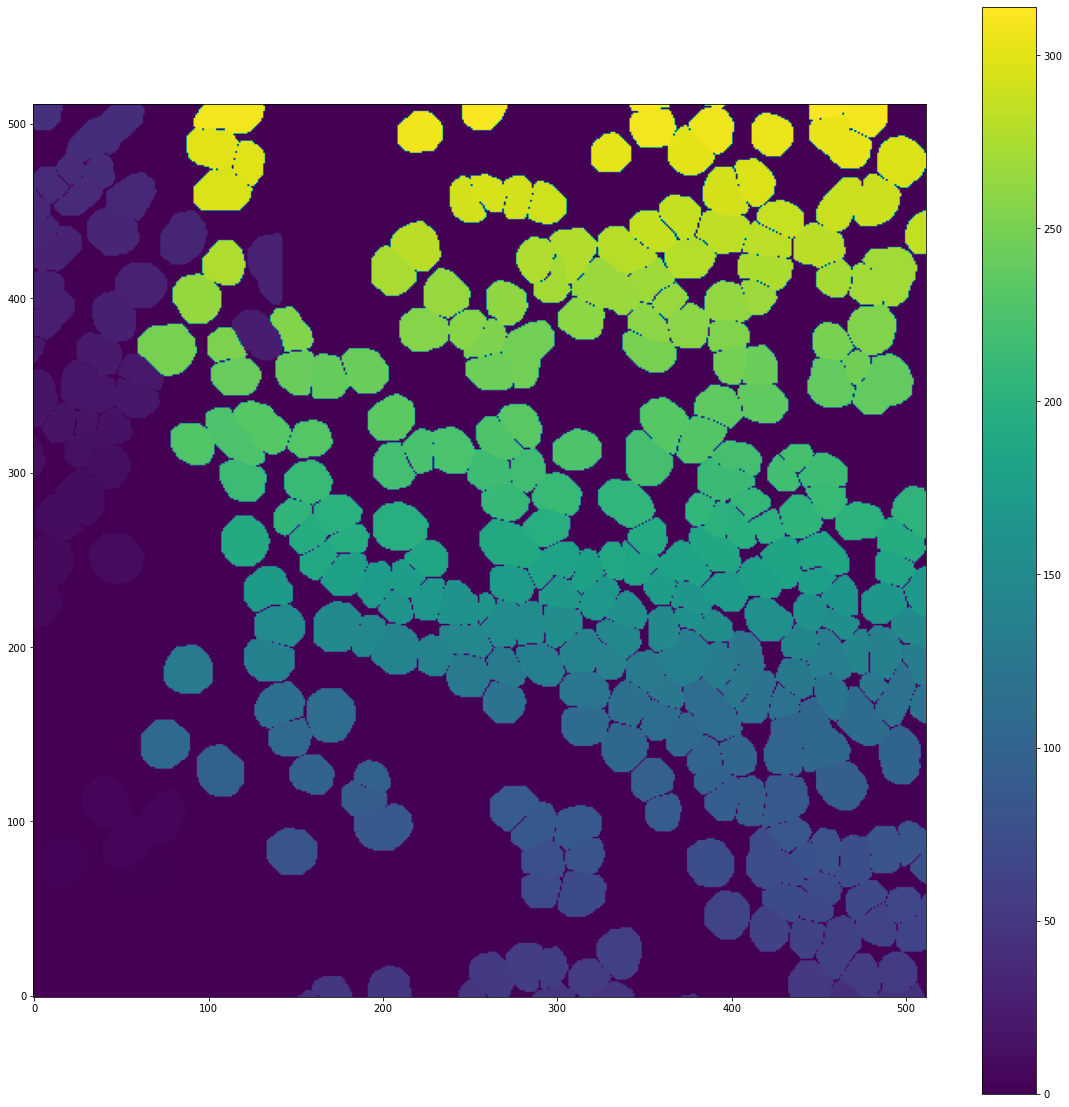

In [4]:
# Visualize
plt.figure(figsize=(20,20))
plt.imshow((a.view), vmin=0, origin='lower')
plt.colorbar()
plt.show()

In [5]:
from tulip import spectral

In [7]:
# Open list with data sets
data = hs_data.data(verbose=True)
data.path = '/mnt/c/Users/Roger/Documents/Doctoral Studies/Data/2022_02_01-CellDive/'

(0, '220222-cell-seg-data.pptx', '0.0GB')
(1, 'VAN0061-LK-2-6-cell-ims-intersections.h5', '0.01GB')
(2, 'VAN0061-LK-2-6-cell-measurements.h5', '0.08GB')
(3, 'VAN0061-LK-2-6-peakpicked-IMS-data.h5', '0.64GB')
(4, 'VAN0061-LK-2-6-toIMS-IMSML-coords.h5', '0.0GB')


In [8]:
# Filter specific data sets from list above
data.filter(ids=0, filter_type="delete")

4 file(s) in selection.


In [9]:
# Load data sets in selection
data.load('ims')

In [10]:
data.path = '/mnt/c/Users/Roger/Documents/Doctoral Studies/Data/2022_02_01-CellDive/per-ims-pix'

(0, 'VAN0061-LK-2-6-cell-ims-intersections-per-ims-pix-fixed.h5', '0.01GB')
(1, 'VAN0061-LK-2-6-cell-ims-intersections-per-ims-pix.h5', '0.01GB')
(2, 'VAN0061-LK-2-6-non-cell-area-per-ims-pix-fixed.h5', '0.0GB')
(3, 'VAN0061-LK-2-6-non-cell-area-per-ims-pix.h5', '0.0GB')


In [11]:
# Filter specific data sets from list above
data.filter(ids=[0,2])

2 file(s) in selection.


In [12]:
# Load data sets in selection
data.load('imsc')

In [13]:
#a = reshape_image(data.data['ims'][2]['peak_data'][:,:], data.data['ims'][2]['xy'][:,0], data.data['ims'][2]['xy'][:,1], None)
input_data = data.data['ims'][2]['peak_data'][:,:].astype(np.float32)

# Image Shape
im_shape = (data.data['ims'][3]['xy_minimized'][:,1].max()+1, data.data['ims'][3]['xy_minimized'][:,0].max()+1)

# Total shape
shape = input_data.shape

# Pixel Order
pixel_order = np.linspace(0, shape[0]-1, shape[0], dtype=int)

In [14]:
# Create sparse V matrix
V = scipy.sparse.dok_matrix((shape[0], data.data['imsc'][0]['cell_idx_factorized'].max()+1), dtype=np.float32)
# Fill V matrix
V[data.data['imsc'][0]['ims_idx'], data.data['imsc'][0]['cell_idx_factorized']] = data.data['imsc'][0]['pixel_area_overlap'] 

In [15]:
b = spectral()

In [16]:
b.from_real(V, input_data, 'a >= 0.99999', 10, annotation = 'cell')

In [17]:
b.from_real(V, input_data, 'a.sum(axis=1) < 0.00001', 1, annotation = 'nar')

In [18]:
type(b)

cynth.spectral.spectral

In [19]:
import tulip as tulip

In [20]:
c = tulip.tulip(a, b)

In [21]:
c.link()

In [22]:
qq = c.downsample(16)

In [23]:
c.spectra.shape

(315, 1093)

In [24]:
c.overlap

<1024x315 sparse matrix of type '<class 'numpy.float32'>'
	with 2630 stored elements in Dictionary Of Keys format>

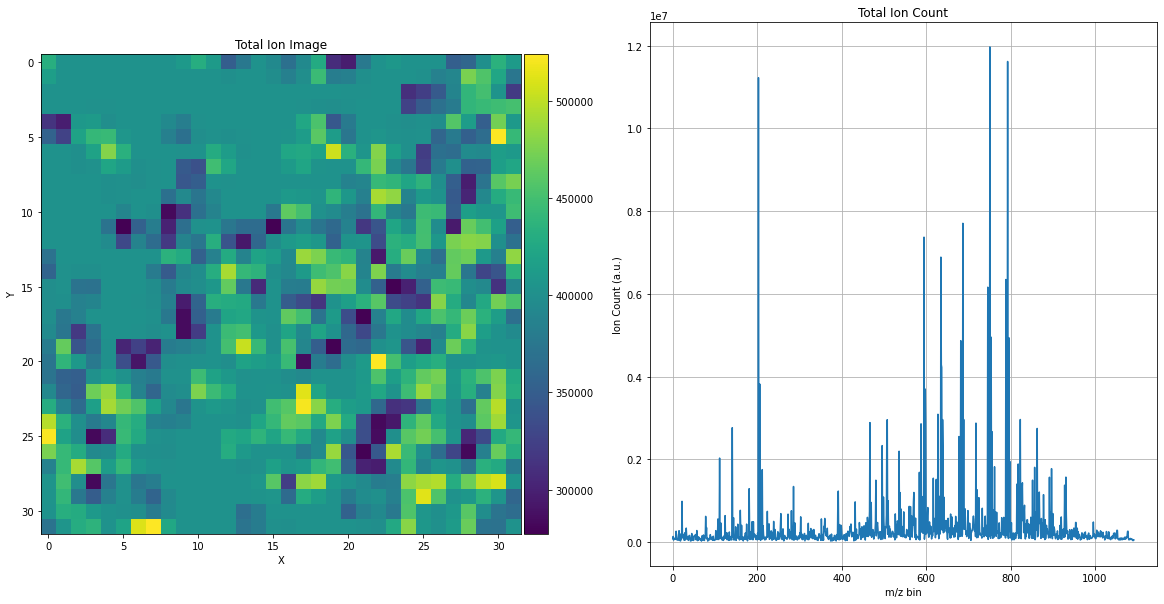

In [25]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
im = axs[0].imshow(c.mixed_block.sum(axis=2), aspect='equal')

divider = make_axes_locatable(axs[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical')
axs[0].set_title('Total Ion Image')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')

axs[1].plot(c.mixed_block.sum(axis=(0, 1)))
axs[1].grid()
axs[1].set_title('Total Ion Count')
axs[1].set_xlabel('m/z bin')
axs[1].set_ylabel('Ion Count (a.u.)')

plt.show()

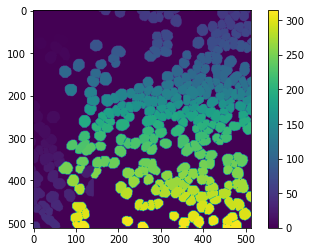

In [26]:
plt.imshow(a.view)
plt.colorbar()
plt.show()

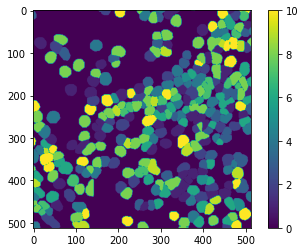

In [27]:
plt.imshow(c.class_image)
plt.colorbar()
plt.show()

In [28]:
from tulip import unmix

In [29]:
u = unmix()

In [30]:
u.solve_ls(c.overlap, c.mixed)
# u.solve_nnls(c.overlap, c.mixed)
# u.solve_nnm(c.overlap, c.mixed, lambda_factor=0.1)
# u.solve_nn_nnm(c.overlap, c.mixed, lambda_factor=0.1)

In [42]:
100-np.linalg.norm(c.spectra-u.c, 'fro')/np.linalg.norm(c.spectra, 'fro')*100

99.98186763259582

In [32]:
from tulip import measures

In [33]:
m = measures(a, b, c, u)

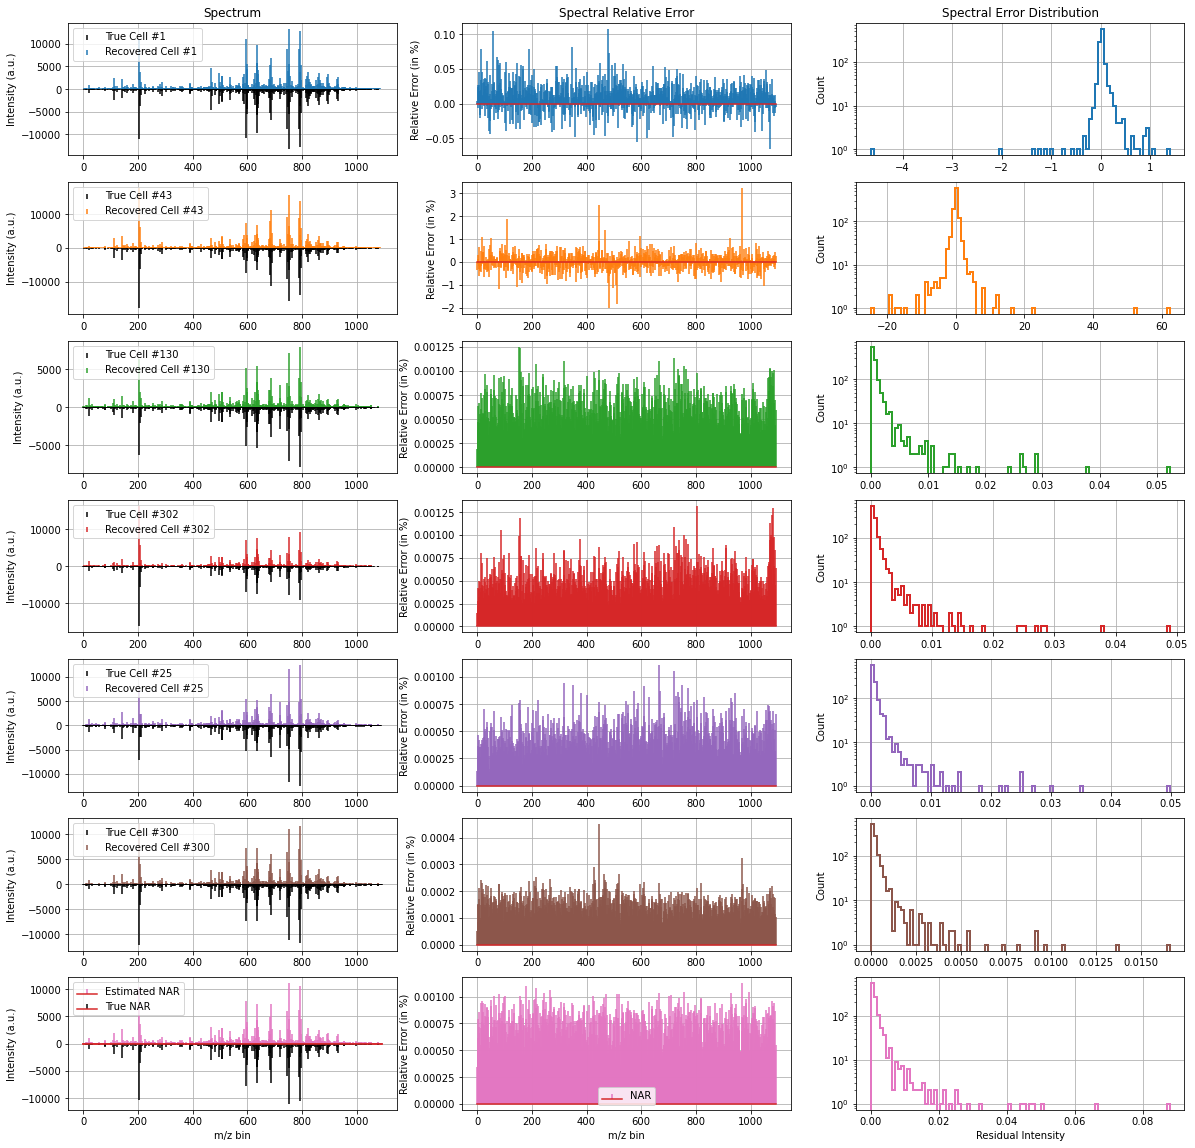

In [34]:
ran = [1, 43, 130, 302, 25, 300]
m.panel_plot(ran)

In [35]:
m.nn_entries()

(array([1., 1., 1., ..., 1., 1., 1.]),
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1

In [36]:
m.fit()

(99.98186763259582, 99.9813163492945)

/mnt/c/Users/Roger/Documents/Doctoral Studies/Code/Python/2022-02-26-heath/cynth/measures.py:53: RuntimeWarning: divide by zero encountered in true_divide
  (self._cynth.spectra - self._unmix.c) / self._cynth.spectra,


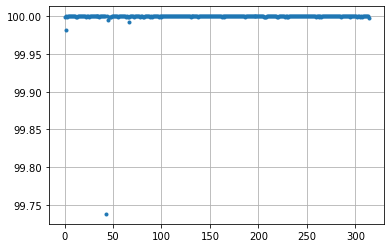

In [37]:
plt.plot(m.cell_fit()[0], '.')
plt.grid()
plt.show()

/mnt/c/Users/Roger/Documents/Doctoral Studies/Code/Python/2022-02-26-heath/cynth/measures.py:53: RuntimeWarning: divide by zero encountered in true_divide
  (self._cynth.spectra - self._unmix.c) / self._cynth.spectra,


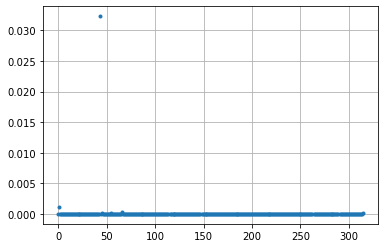

In [38]:
plt.plot(m.cell_fit()[1], '.')
plt.grid()
plt.show()

In [39]:
m.clustering_measure()

(100.0,
 array([5.1320803e-05, 2.2738228e-04, 2.0506217e-04, 7.7074001e-05,
        7.1238475e-03, 4.7081896e-05, 2.4744854e-04, 1.9771536e-04,
        6.8145373e-04, 6.8108573e-05], dtype=float32))

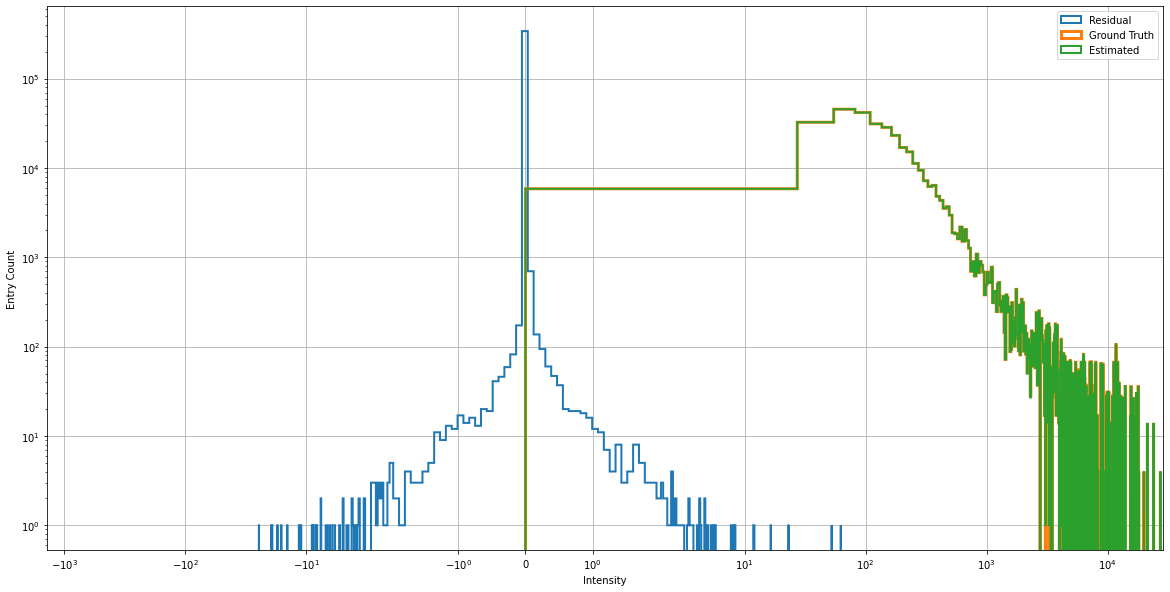

In [41]:
m.bin_plot()

In [ ]:
# a.view is an image of size

In [1]:
a.view.shape

NameError: name 'a' is not defined